### 📘 **Introduction to Graphs - Summary**

**1. What is a Graph?**

* A **graph** is a data structure made up of a **set of nodes (vertices)** and **edges** (connections between nodes).
* It is **similar to a tree**, but without the strict hierarchical structure.
* In a graph, nodes can be connected in any form—no fixed pattern like a tree.

**2. Real-World Examples of Graphs**
Graphs are widely used to model real-world systems:

* **Social Networks (e.g., Facebook, Instagram)**:
  Users are nodes; friendships/followings are edges.
* **City Maps and Road Networks**:
  Cities/intersections are nodes; roads are edges.
* **Railway or Flight Networks**:
  Stations/airports are nodes; tracks/routes are edges.

**3. Why Do We Need Graphs?**

* Graphs help represent complex, interconnected data that other data structures can't efficiently model.
* Useful for solving problems involving relationships, navigation, connectivity, and more.

**4. Industry Use Cases**

* **Navigation Systems (e.g., Google Maps)**:
  Graphs power route calculations and map representations.
* **Search Engines (e.g., Google's PageRank)**:
  Webpages are nodes; hyperlinks are directed edges. The PageRank algorithm uses this graph to rank pages.
* **Social Network Modeling in Industry**:
  Teams, connections, and interactions are all modeled as graphs.

**5. Difference Between Tree and Graph**
A **tree is a special type of graph** with two key properties:

* **Every node is connected** (no isolated nodes).
* **No cycles allowed** (a cycle means a path that starts and ends at the same node).
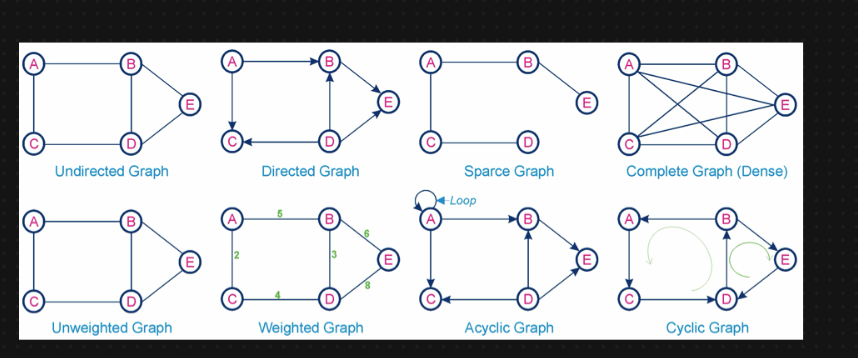


# 

# Graph implementation using Edge list

In [1]:
class GraphUsingEdgeList:

    def __init__(self):
        self.V = []
        self.edges = []

    def add_vertex(self,vertex):
        if( vertex not in self.V):
            self.V.append(vertex)
        else:
            print(f"{vertex} already exists")
        return 

    def add_edge(self,source,destination,weight =1):
        if source in self.V and destination in self.V:
            edge = (source,destination,weight)
            self.edges.append(edge)
        else:
            print("One or both the vertices are not found")
    
    def display(self):
        print("Vertices")
        for vertex in self.V:
            print(f"Vertex: {vertex}")
        for source,destination,weight in self.edges:
            print(f"{source} ---> {destination}")




graph = GraphUsingEdgeList()
graph.add_vertex(1)
graph.add_vertex(2)
graph.add_vertex(3)

graph.add_edge(1,2)
graph.add_edge(2,3)

graph.display()



Vertices
Vertex: 1
Vertex: 2
Vertex: 3
1 ---> 2
2 ---> 3


# Graph using adjacency list

In [2]:
class GraphAdjacencyList:
    def __init__(self):
        self.V = []
        self.adj_list = {}
    
    def add_vertex(self,vertex):
        if(vertex not in self.V):
            self.V.append(vertex)
            self.adj_list[vertex] = []
        else:
            print(f"Vertex {vertex} already exists")
        
    def add_edges(self,source,destination,weight=1):
            if source in self.V and destination in self.V:
                self.adj_list[source].append((destination,weight))
                self.adj_list[destination].append((source,weight)) # Assuming Undirected Graph
            else:
                 print("One or both vertices not found.")
        
    def display(self):
        # for vertex in self.V:
        #       print(f"Vertex -> {vertex}")
        
        for vertex, neighbour in self.adj_list.items():
                print(f"{vertex} : {neighbour}")


graph = GraphAdjacencyList()
graph.add_vertex('A')
graph.add_vertex('B')
graph.add_vertex('C')
graph.add_vertex('D')
graph.add_vertex('E')

graph.add_edges('A','B')
graph.add_edges('A','D')
graph.add_edges('B','D')
graph.add_edges('B','C')

graph.display()



A : [('B', 1), ('D', 1)]
B : [('A', 1), ('D', 1), ('C', 1)]
C : [('B', 1)]
D : [('A', 1), ('B', 1)]
E : []


# Graph using adjacency  matrix

In [3]:
# https://visualgo.net/en/graphds

class GraphAdjacencyMatrix:
    def __init__(self,num_vertices):
        self.num_vertices = num_vertices
        self.vertices = [None] * num_vertices
        self.adj_matrix = [ [0] * num_vertices for row in range(num_vertices)]
    
    def add_vertex(self,index,label):
        if( index >=0 and index <self.num_vertices):
            self.vertices[index] = label
        else:
            print("Index OOB")

    def add_edge(self,source,destination,weight=1):
        if 0 <= source < self.num_vertices and 0<= destination <self.num_vertices:
            self.adj_matrix[source][destination] = weight
            self.adj_matrix[destination][source] = weight # Undirected Graph
    
    def display(self):

        for index ,label in enumerate(self.vertices):
            if label !=None:
                print(f"Vertex Index : {index}, label :{label} ")
        
        for row in self.adj_matrix:
            print(row)

graph = GraphAdjacencyMatrix(3)
graph.add_vertex(0,'A')
graph.add_vertex(1,'B')
graph.add_vertex(2,'C')
graph.add_vertex(3,'D')

graph.add_edge(0,1)
graph.add_edge(1,2)

graph.display()



Index OOB
Vertex Index : 0, label :A 
Vertex Index : 1, label :B 
Vertex Index : 2, label :C 
[0, 1, 0]
[1, 0, 1]
[0, 1, 0]


# BFS

In [15]:
from collections import deque

def BFS(graph, start):
    visited = set()  # Keep track of the nodes that we've visited
    queue = deque([start])  # Use a queue to implement the BFS

    while queue:
        node = queue.popleft()  # Dequeue a node from front of queue
        if node not in visited:
            visited.add(node)  # Mark the node as visited
            print(node, end=' ')  # Visit the node (print its value in this case)
            queue.extend(graph[node])  # Enqueue all neighbours

# Use the BFS function on a graph
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E'],
}

BFS(graph, 'A')  # Output: A B C D E F

A B C D E F 

In [17]:
def DFS(graph, start):
    visited = set()  # keep track of the visited nodes
    stack = [start]  # use a stack to keep track of nodes to visit next

    while stack:
        node = stack.pop()  # get the next node to visit
        if node not in visited:
            visited.add(node)  # mark the node as visited
            print(node, end=' ')  # visit the node (print its value in this case)
            stack.extend(graph[node])  # add the node's neighbors to the stack

# Use the DFS function on a graph
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E'],
}

DFS(graph, 'A')  # Output: A C F E B D

A C F E B D 